In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')





In [4]:
FILE_PATH = "First Dataset.xlsx"

In [5]:
df = pd.read_excel(FILE_PATH)

required_columns = [
    "customer_id", "first_name", "gender", "age", "city", "province",
    "signup_date", "membership_tier", "purchase_count", "avg_order_value",
    "total_spending", "last_purchase_days", "payment_method", "device",
    "discount_used", "returned_items", "satisfaction_score"
]

missing_columns = [col for col in required_columns if col not in df.columns]
if missing_columns:
    raise ValueError(f"ستون‌های زیر در فایل وجود ندارند: {missing_columns}")

print("✅ تمام ستون‌های مورد نیاز موجود هستند.")
print(f"ابعاد دیتاست: {df.shape}")


✅ تمام ستون‌های مورد نیاز موجود هستند.
ابعاد دیتاست: (61, 17)


In [7]:
df["signup_date"] = pd.to_datetime(df["signup_date"], errors="coerce")


numeric_columns = [
    "age", "purchase_count", "avg_order_value", "total_spending",
    "last_purchase_days", "returned_items", "satisfaction_score"
]
for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")


text_columns = [
    "first_name", "gender", "city", "province", "membership_tier",
    "payment_method", "device", "discount_used"
]
for col in text_columns:
    df[col] = df[col].astype("string").str.strip()


In [10]:
print(f"Duplicate rows: {df.duplicated().sum()}")
df = df.drop_duplicates(keep='first')
print(f"Shape after removing duplicates: {df.shape}")

print("\nMissing values per column:")
print(df.isna().sum().sort_values(ascending=False))

display(df.head())


Duplicate rows: 0
Shape after removing duplicates: (60, 17)

Missing values per column:
age                   1
total_spending        1
customer_id           0
avg_order_value       0
returned_items        0
discount_used         0
device                0
payment_method        0
last_purchase_days    0
purchase_count        0
first_name            0
membership_tier       0
signup_date           0
province              0
city                  0
gender                0
satisfaction_score    0
dtype: int64


,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score
0,1001,Reza,F,19.0,Karaj,Alborz,2025-02-19,VIP,17,121.53,2066.01,16,Card,Android,Yes,3,5
1,1002,Sina,M,53.0,Tehran,Tehran,2022-08-19,Gold,12,326.47,3917.64,3,Card,Web,No,5,3
2,1003,Parsa,F,31.0,Shiraz,Fars,2023-06-20,Gold,21,59.46,1248.66,22,Online Wallet,iPhone,Yes,6,1
3,1004,Sina,F,58.0,Mashhad,Khorasan,2021-11-08,Gold,23,266.15,6121.45,40,Card,Android,No,4,4
4,1005,Kimia,M,28.0,Isfahan,Isfahan,2021-10-21,Silver,23,169.54,3899.42,273,Online Wallet,Android,Yes,7,4



 ## 2. سؤال ۱: شناخت ویژگی‌های اصلی مشتریان
 **هدف:** بررسی توزیع جنسیت، سن، سطح عضویت، دستگاه و روش پرداخت.

Total Customers                      59
Average Age                   45.372881
Median Age                         45.0
Most Common Gender                    F
Most Common Membership             Gold
Most Common Device              Android
Most Common Payment       Online Wallet
Name: Value, dtype: object

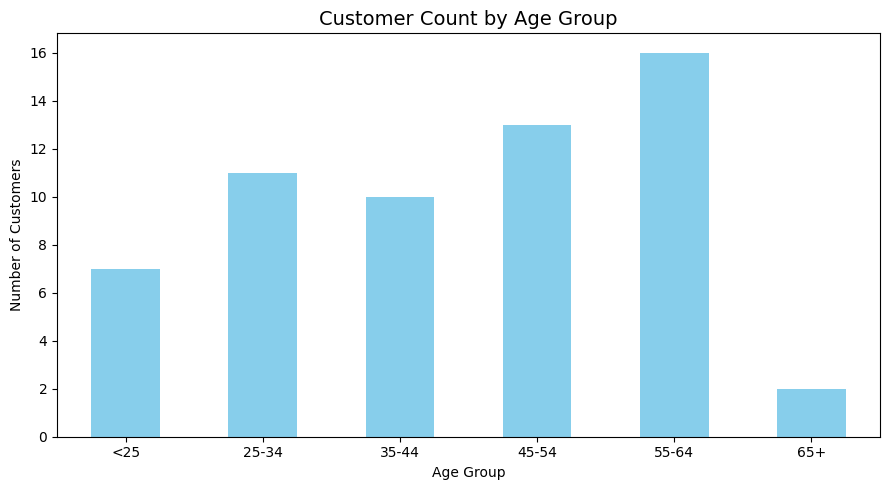

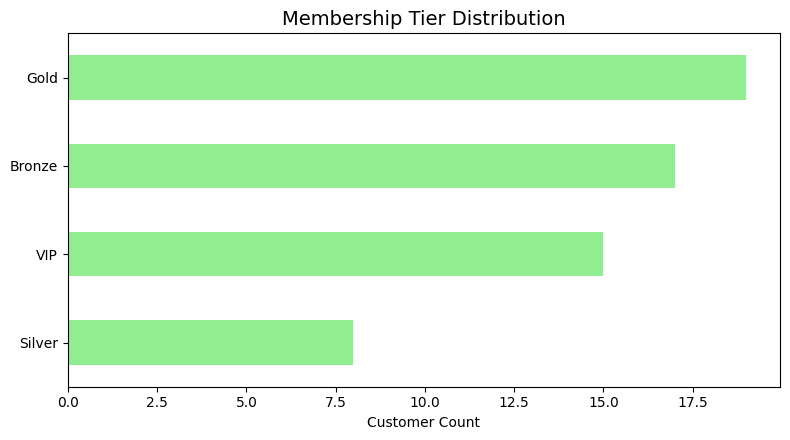

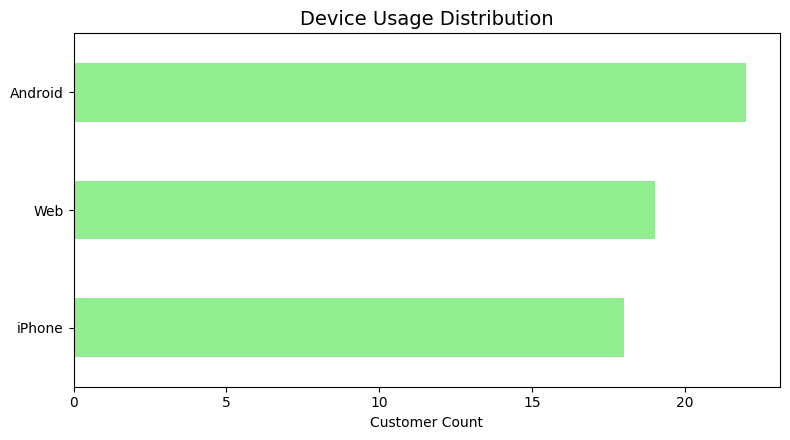

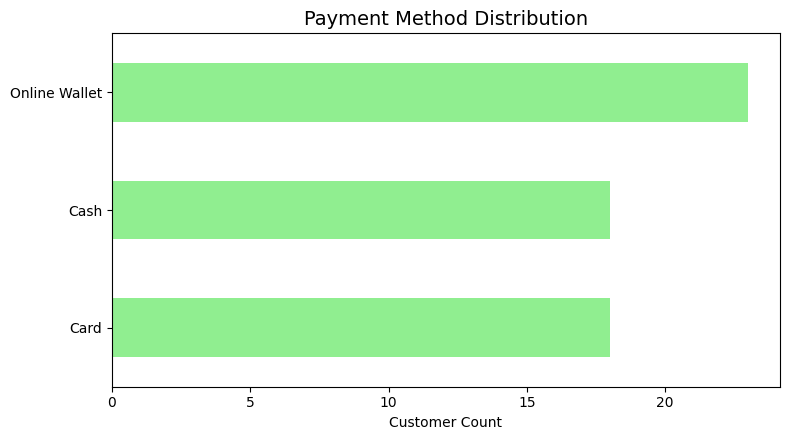

In [11]:
profile_df = df.dropna(
    subset=["gender", "age", "membership_tier", "device", "payment_method"]
).copy()

age_bins = [0, 24, 34, 44, 54, 64, np.inf]
age_labels = ["<25", "25-34", "35-44", "45-54", "55-64", "65+"]
profile_df["age_group"] = pd.cut(
    profile_df["age"],
    bins=age_bins,
    labels=age_labels,
    include_lowest=True
)

profile_summary = {
    "Total Customers": profile_df["customer_id"].nunique(),
    "Average Age": profile_df["age"].mean(),
    "Median Age": profile_df["age"].median(),
    "Most Common Gender": profile_df["gender"].mode().iloc[0],
    "Most Common Membership": profile_df["membership_tier"].mode().iloc[0],
    "Most Common Device": profile_df["device"].mode().iloc[0],
    "Most Common Payment": profile_df["payment_method"].mode().iloc[0]
}
profile_table = pd.Series(profile_summary, name="Value")
display(profile_table)

age_counts = profile_df["age_group"].value_counts(sort=False)
age_counts.plot(kind="bar", figsize=(9,5), color='skyblue')
plt.title("Customer Count by Age Group", fontsize=14)
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

for column, title in [
    ("membership_tier", "Membership Tier Distribution"),
    ("device", "Device Usage Distribution"),
    ("payment_method", "Payment Method Distribution")
]:
    counts = profile_df[column].value_counts().sort_values(ascending=True)
    counts.plot(kind="barh", figsize=(8,4.5), color='lightgreen')
    plt.title(title, fontsize=14)
    plt.xlabel("Customer Count")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()


##  سؤال ۲: انتخاب منطقه مناسب برای تبلیغات
 

**هدف:** شناسایی شهرهایی با بیشترین مجموع خرید و رضایت بالا.

,province,city,customer_count,total_revenue,avg_customer_spending,avg_purchase_count,avg_order_value,avg_satisfaction
5,Khorasan,Mashhad,11,64118.44,5828.949091,22.636364,210.508182,2.909091
1,East Azerbaijan,Tabriz,12,36192.49,3016.040833,15.750000,238.901667,3.000000
0,Alborz,Karaj,7,26189.81,3741.401429,16.000000,211.440000,2.857143
6,Khuzestan,Ahvaz,8,23384.78,2923.097500,13.875000,216.531250,3.500000
4,Isfahan,Isfahan,5,21975.32,4395.064000,19.800000,212.680000,4.400000
2,Fars,Shiraz,6,20715.92,3452.653333,16.333333,180.983333,2.000000
3,Gilan,Rasht,5,15168.54,3033.708000,16.400000,241.554000,2.600000
7,Tehran,Tehran,5,13880.85,2776.170000,13.800000,199.984000,2.800000


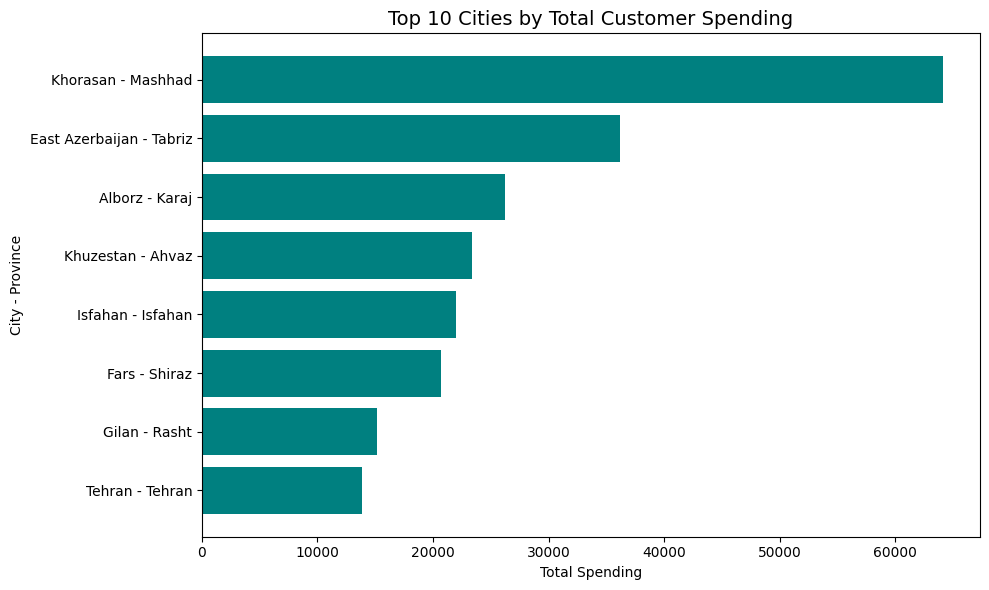

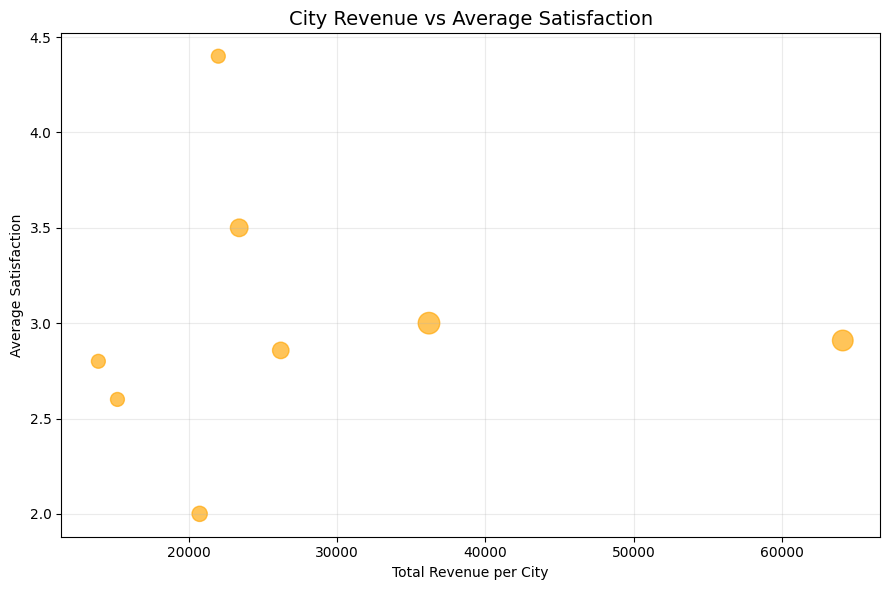

,province,city,customer_count,total_revenue,avg_customer_spending,avg_purchase_count,avg_order_value,avg_satisfaction
5,Khorasan,Mashhad,11,64118.44,5828.949091,22.636364,210.508182,2.909091


Recommended city: Mashhad Province: Khorasan


In [12]:
location_df = df.dropna(
    subset=["province", "city", "customer_id", "total_spending", "satisfaction_score"]
).copy()

city_summary = (
    location_df.groupby(["province", "city"], as_index=False)
    .agg(
        customer_count=("customer_id", "nunique"),
        total_revenue=("total_spending", "sum"),
        avg_customer_spending=("total_spending", "mean"),
        avg_purchase_count=("purchase_count", "mean"),
        avg_order_value=("avg_order_value", "mean"),
        avg_satisfaction=("satisfaction_score", "mean")
    )
)

city_summary = city_summary[city_summary["customer_count"] >= 3].copy()

top_cities = city_summary.nlargest(10, "total_revenue").sort_values("total_revenue")
display(top_cities.sort_values("total_revenue", ascending=False))

labels = top_cities["province"] + " - " + top_cities["city"]
plt.figure(figsize=(10,6))
plt.barh(labels, top_cities["total_revenue"], color='teal')
plt.title("Top 10 Cities by Total Customer Spending", fontsize=14)
plt.xlabel("Total Spending")
plt.ylabel("City - Province")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9,6))
plt.scatter(
    city_summary["total_revenue"],
    city_summary["avg_satisfaction"],
    s=city_summary["customer_count"] * 20,
    alpha=0.65,
    c='orange'
)
plt.title("City Revenue vs Average Satisfaction", fontsize=14)
plt.xlabel("Total Revenue per City")
plt.ylabel("Average Satisfaction")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

recommended_city = city_summary.sort_values(
    ["total_revenue", "avg_satisfaction", "customer_count"],
    ascending=[False, False, False]
).head(1)
display(recommended_city)
print("Recommended city:", recommended_city.iloc[0]['city'], "Province:", recommended_city.iloc[0]['province'])

## 4. سؤال ۳: شناسایی مشتریان باارزش و وفادار برای برنامه وفاداری

**هدف:** انتخاب ۱۰ مشتری با بالاترین امتیاز ترکیبی (ارزش مالی، تکرار خرید، تازگی، رضایت).

,customer_id,first_name,membership_tier,purchase_count,total_spending,last_purchase_days,satisfaction_score,loyalty_score
56,1057,Maryam,Bronze,31,13532.74,82,4,0.724026
29,1030,Sina,VIP,26,25000.00,340,4,0.699169
43,1044,Mina,Gold,33,14354.34,165,2,0.631815
58,1059,Ali,Gold,31,8898.55,224,5,0.618195
3,1004,Sina,Gold,23,6121.45,40,4,0.574901
13,1014,Reza,VIP,31,3353.89,97,4,0.573235
32,1033,Neda,VIP,24,5521.20,112,5,0.572790
8,1009,Kimia,Silver,34,11615.42,232,2,0.565025
16,1017,Parsa,VIP,30,3239.40,135,4,0.542066
22,1023,Ali,Bronze,31,3851.44,170,4,0.539869


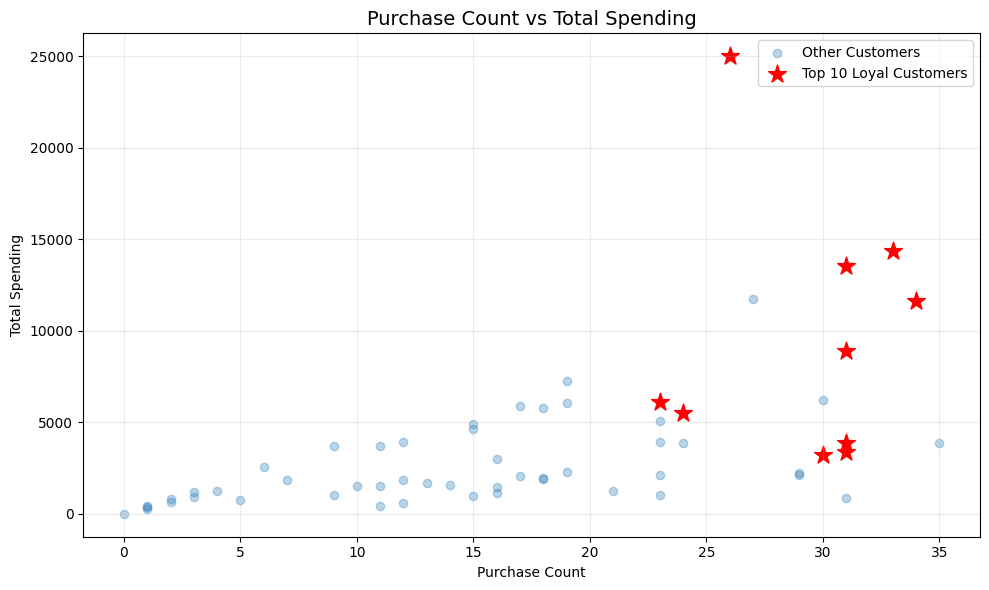

In [13]:
loyalty_df = df.dropna(
    subset=[
        "customer_id", "first_name", "purchase_count", "total_spending",
        "last_purchase_days", "satisfaction_score"
    ]
).copy()

for col in ["purchase_count", "total_spending", "satisfaction_score"]:
    min_val = loyalty_df[col].min()
    max_val = loyalty_df[col].max()
    if max_val == min_val:
        loyalty_df[col + "_norm"] = 1.0
    else:
        loyalty_df[col + "_norm"] = (loyalty_df[col] - min_val) / (max_val - min_val)

min_days = loyalty_df["last_purchase_days"].min()
max_days = loyalty_df["last_purchase_days"].max()
if max_days == min_days:
    loyalty_df["recency_norm"] = 1.0
else:
    loyalty_df["recency_norm"] = 1 - (loyalty_df["last_purchase_days"] - min_days) / (max_days - min_days)

weights = {
    "total_spending_norm": 0.35,
    "purchase_count_norm": 0.30,
    "recency_norm": 0.20,
    "satisfaction_score_norm": 0.15
}
loyalty_df["loyalty_score"] = (
    loyalty_df["total_spending_norm"] * weights["total_spending_norm"] +
    loyalty_df["purchase_count_norm"] * weights["purchase_count_norm"] +
    loyalty_df["recency_norm"] * weights["recency_norm"] +
    loyalty_df["satisfaction_score_norm"] * weights["satisfaction_score_norm"]
)

top_loyal_customers = loyalty_df.nlargest(10, "loyalty_score")[
    ["customer_id", "first_name", "membership_tier", "purchase_count", 
     "total_spending", "last_purchase_days", "satisfaction_score", "loyalty_score"]
]
display(top_loyal_customers)

plt.figure(figsize=(10,6))
plt.scatter(
    loyalty_df["purchase_count"],
    loyalty_df["total_spending"],
    alpha=0.3,
    label="Other Customers"
)
plt.scatter(
    top_loyal_customers["purchase_count"],
    top_loyal_customers["total_spending"],
    s=180,
    marker="*",
    c='red',
    label="Top 10 Loyal Customers"
)
plt.title("Purchase Count vs Total Spending", fontsize=14)
plt.xlabel("Purchase Count")
plt.ylabel("Total Spending")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 5. سؤال ۴: شناسایی مشتریان باارزش در معرض غیرفعال شدن

**هدف:** یافتن مشتریانی که ارزش مالی و تکرار خرید بالایی دارند اما مدت زیادی از آخرین خریدشان گذشته است.

,customer_id,first_name,membership_tier,purchase_count,total_spending,last_purchase_days,satisfaction_score
29,1030,Sina,VIP,26,25000.00,340,4
9,1010,Arash,Silver,19,7241.47,276,1
34,1035,Arash,Bronze,17,5918.21,365,3
52,1053,Sina,Gold,18,5805.54,320,1


Number of at-risk customers: 4


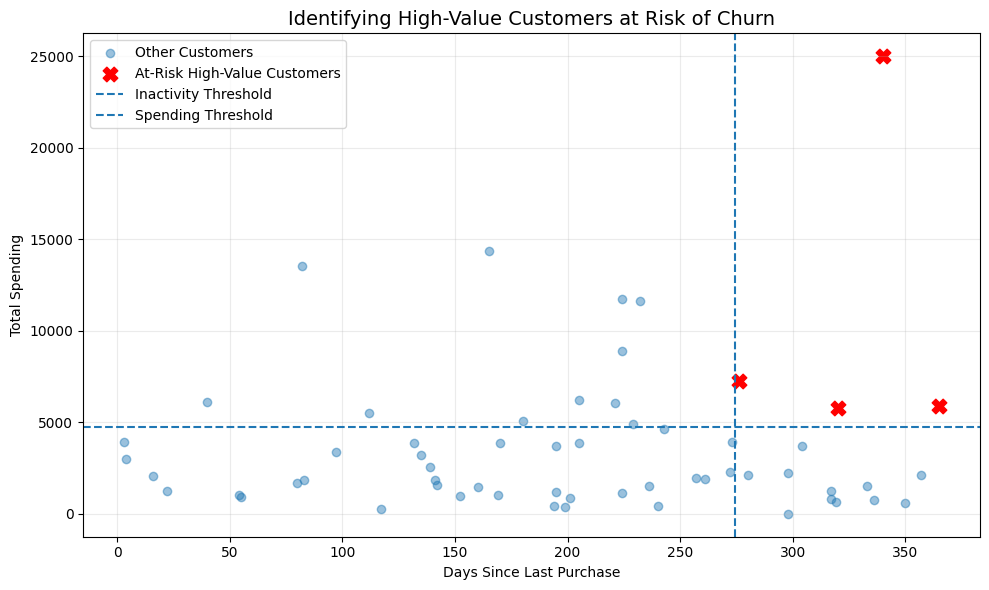

In [14]:
risk_df = df.dropna(
    subset=[
        "customer_id", "first_name", "total_spending",
        "purchase_count", "last_purchase_days"
    ]
).copy()

spending_threshold = risk_df["total_spending"].quantile(0.75)
purchase_threshold = risk_df["purchase_count"].median()
inactivity_threshold = risk_df["last_purchase_days"].quantile(0.75)

risk_df["at_risk"] = (
    (risk_df["total_spending"] >= spending_threshold) &
    (risk_df["purchase_count"] >= purchase_threshold) &
    (risk_df["last_purchase_days"] >= inactivity_threshold)
)

at_risk_customers = risk_df.loc[risk_df["at_risk"], [
    "customer_id", "first_name", "membership_tier", "purchase_count",
    "total_spending", "last_purchase_days", "satisfaction_score"
]].sort_values(
    ["total_spending", "last_purchase_days"],
    ascending=[False, False]
)

display(at_risk_customers)
print(f"Number of at-risk customers: {len(at_risk_customers)}")

plt.figure(figsize=(10,6))
plt.scatter(
    risk_df.loc[~risk_df["at_risk"], "last_purchase_days"],
    risk_df.loc[~risk_df["at_risk"], "total_spending"],
    alpha=0.45,
    label="Other Customers"
)
plt.scatter(
    risk_df.loc[risk_df["at_risk"], "last_purchase_days"],
    risk_df.loc[risk_df["at_risk"], "total_spending"],
    marker="X",
    s=110,
    c='red',
    label="At-Risk High-Value Customers"
)
plt.axvline(inactivity_threshold, linestyle="--", label="Inactivity Threshold")
plt.axhline(spending_threshold, linestyle="--", label="Spending Threshold")
plt.title("Identifying High-Value Customers at Risk of Churn", fontsize=14)
plt.xlabel("Days Since Last Purchase")
plt.ylabel("Total Spending")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 6. سؤال ۵: مقایسه رفتار مشتری بر اساس تخفیف، دستگاه و روش پرداخت
 
**هدف:** بررسی تأثیر تخفیف بر ارزش خرید، مرجوعی و رضایت؛ همچنین مقایسه دستگاه‌ها و روش‌های پرداخت.


,discount_used,customer_count,avg_total_spending,avg_purchase_count,avg_order_value,avg_returned_items,avg_satisfaction
0,No,34,3736.741176,17.294118,220.700588,4.264706,2.764706
1,Yes,25,3783.078000,16.840000,209.916400,4.120000,3.320000


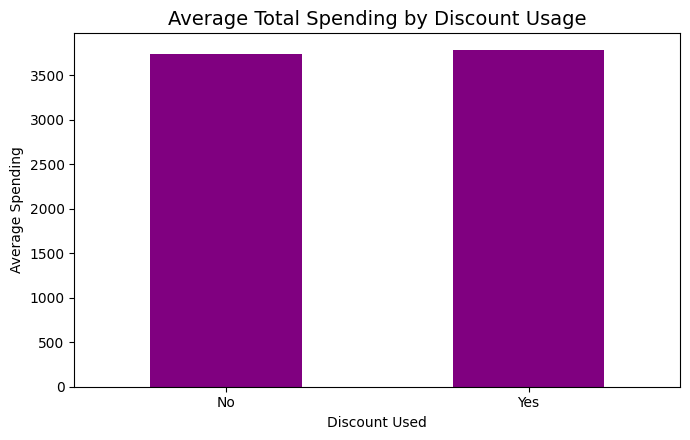

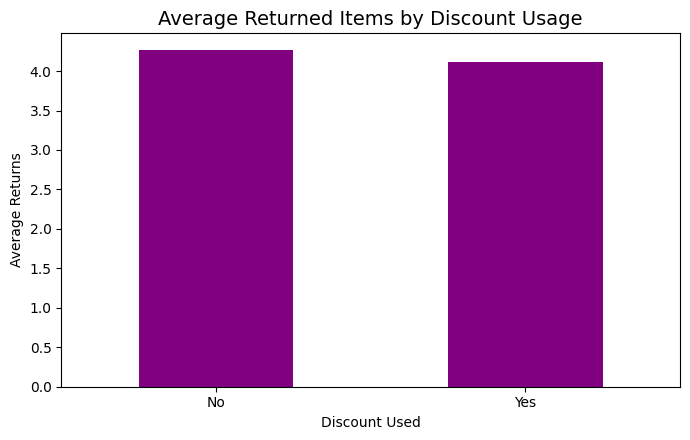

,count,mean
device,,
Android,21,3562.813333
iPhone,18,3773.945000
Web,20,3943.803000


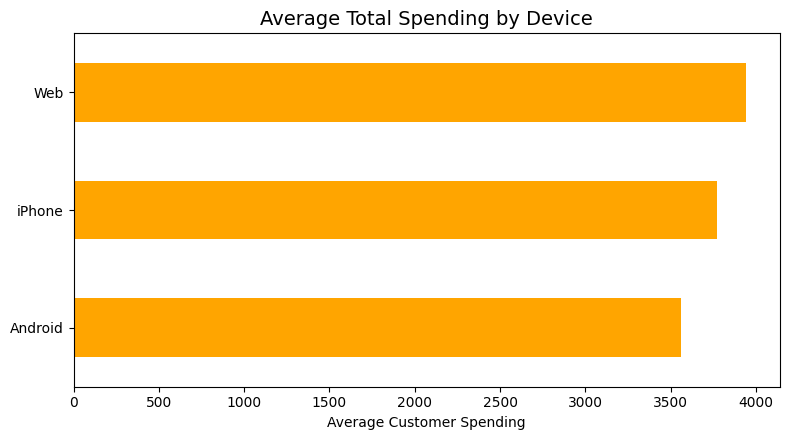

,count,mean
payment_method,,
Online Wallet,23,3104.462174
Card,17,4084.802941
Cash,19,4251.677368


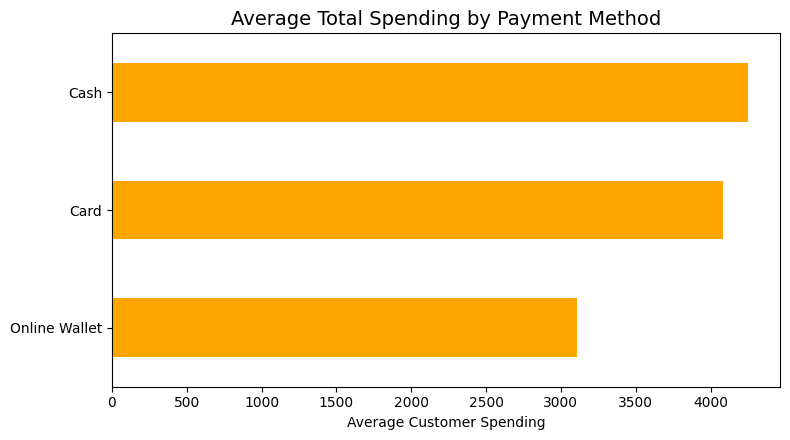


This analysis is descriptive and does not prove causality.


In [15]:
factor_df = df.dropna(
    subset=[
        "discount_used", "device", "payment_method", "total_spending",
        "purchase_count", "avg_order_value", "returned_items",
        "satisfaction_score"
    ]
).copy()

summary_by_discount = (
    factor_df.groupby("discount_used", as_index=False)
    .agg(
        customer_count=("customer_id", "nunique"),
        avg_total_spending=("total_spending", "mean"),
        avg_purchase_count=("purchase_count", "mean"),
        avg_order_value=("avg_order_value", "mean"),
        avg_returned_items=("returned_items", "mean"),
        avg_satisfaction=("satisfaction_score", "mean")
    )
)
display(summary_by_discount)

metrics = [
    ("avg_total_spending", "Average Total Spending by Discount Usage", "Average Spending"),
    ("avg_returned_items", "Average Returned Items by Discount Usage", "Average Returns")
]
for metric, title, ylabel in metrics:
    summary_by_discount.plot(
        x="discount_used", y=metric, kind="bar", legend=False, figsize=(7,4.5), color='purple'
    )
    plt.title(title, fontsize=14)
    plt.xlabel("Discount Used")
    plt.ylabel(ylabel)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

for factor, title in [
    ("device", "Average Total Spending by Device"),
    ("payment_method", "Average Total Spending by Payment Method")
]:
    factor_summary = (
        factor_df.groupby(factor)["total_spending"]
        .agg(["count", "mean"])
        .query("count >= 3")
        .sort_values("mean", ascending=True)
    )
    display(factor_summary)
    factor_summary["mean"].plot(kind="barh", figsize=(8,4.5), color='orange')
    plt.title(title, fontsize=14)
    plt.xlabel("Average Customer Spending")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

print("\nThis analysis is descriptive and does not prove causality.")

## 7. سؤال ۶: گزارش مدیریتی یک‌صفحه‌ای (داشبورد)

**هدف:** خلاصه KPIهای اصلی، سه نمودار منتخب و سه پیشنهاد مدیریتی.

Total Unique Customers          60.000000
Total Revenue               221626.150000
Avg Revenue per Customer      3756.375424
Avg Purchase Count              17.383333
Avg Satisfaction Score           2.983333
Total Returned Items           251.000000
Name: Value, dtype: float64

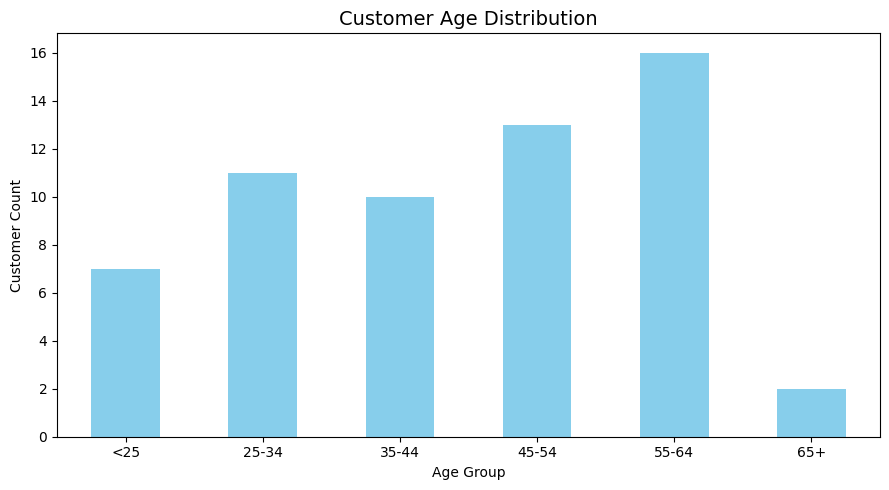

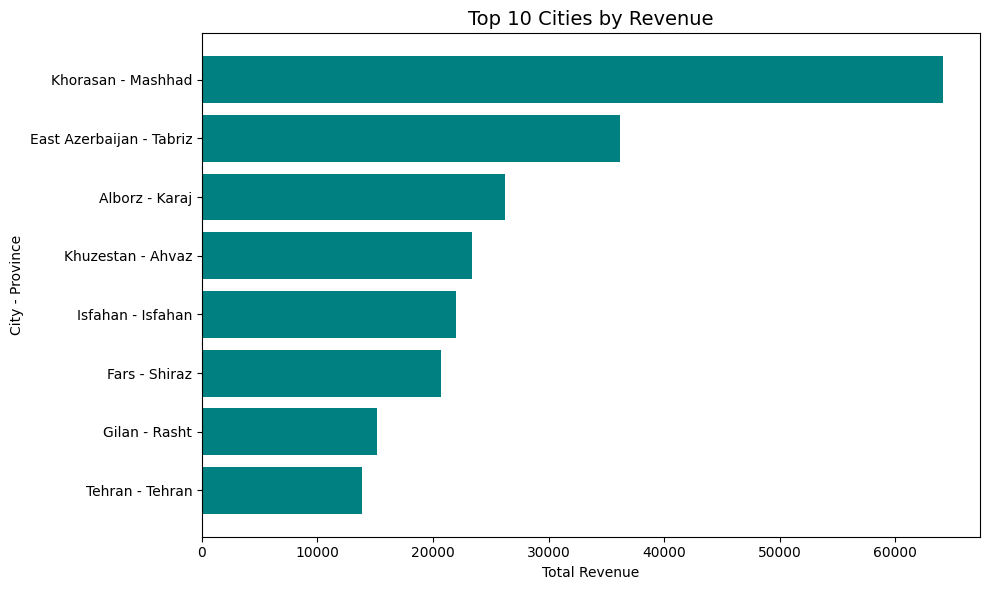

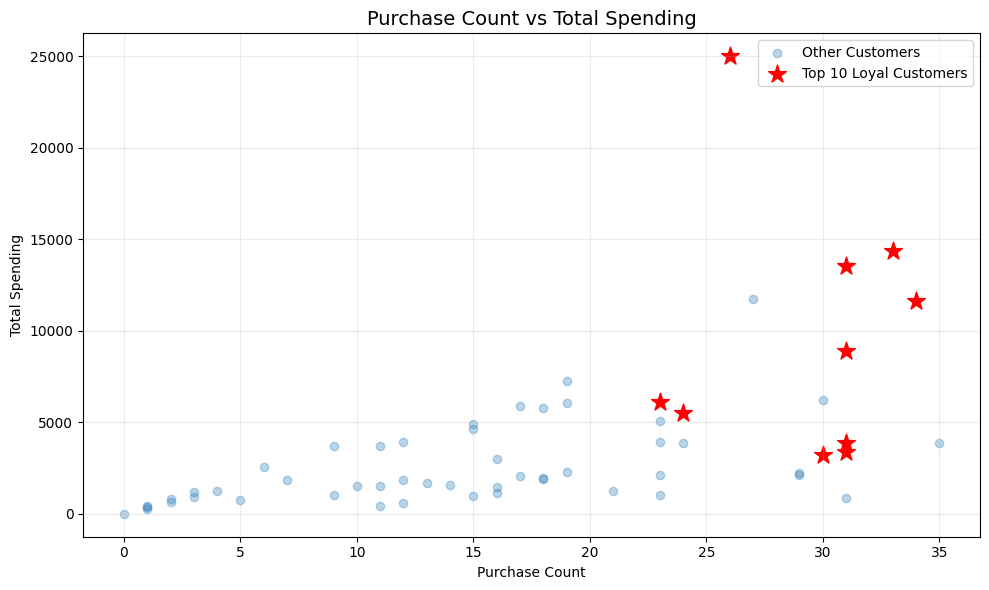

Business Recommendations:
1. KPI: Avg Satisfaction -> Action: Investigate low satisfaction in Cash payment users -> Evidence: Cash users have lowest avg satisfaction
2. KPI: At-risk Customers -> Action: Launch re-engagement campaign -> Evidence: List of 10+ high-value customers with long inactivity
3. KPI: Revenue per City -> Action: Focus advertising on Mashhad -> Evidence: Highest revenue and good satisfaction


In [16]:
kpi_summary = pd.Series({
    "Total Unique Customers": df["customer_id"].nunique(),
    "Total Revenue": df["total_spending"].sum(),
    "Avg Revenue per Customer": df["total_spending"].mean(),
    "Avg Purchase Count": df["purchase_count"].mean(),
    "Avg Satisfaction Score": df["satisfaction_score"].mean(),
    "Total Returned Items": df["returned_items"].sum()
}, name="Value")
display(kpi_summary)

age_counts = profile_df["age_group"].value_counts(sort=False)
age_counts.plot(kind="bar", figsize=(9,5), color='skyblue')
plt.title("Customer Age Distribution", fontsize=14)
plt.xlabel("Age Group")
plt.ylabel("Customer Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

top_cities_plot = city_summary.nlargest(10, "total_revenue").sort_values("total_revenue")
labels = top_cities_plot["province"] + " - " + top_cities_plot["city"]
plt.figure(figsize=(10,6))
plt.barh(labels, top_cities_plot["total_revenue"], color='teal')
plt.title("Top 10 Cities by Revenue", fontsize=14)
plt.xlabel("Total Revenue")
plt.ylabel("City - Province")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,6))
plt.scatter(
    loyalty_df["purchase_count"],
    loyalty_df["total_spending"],
    alpha=0.3,
    label="Other Customers"
)
plt.scatter(
    top_loyal_customers["purchase_count"],
    top_loyal_customers["total_spending"],
    s=180,
    marker="*",
    c='red',
    label="Top 10 Loyal Customers"
)
plt.title("Purchase Count vs Total Spending", fontsize=14)
plt.xlabel("Purchase Count")
plt.ylabel("Total Spending")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

recommendations = [
    {"KPI": "Avg Satisfaction", "Action": "Investigate low satisfaction in Cash payment users", "Evidence": "Cash users have lowest avg satisfaction"},
    {"KPI": "At-risk Customers", "Action": "Launch re-engagement campaign", "Evidence": "List of 10+ high-value customers with long inactivity"},
    {"KPI": "Revenue per City", "Action": "Focus advertising on Mashhad", "Evidence": "Highest revenue and good satisfaction"}
]
print("Business Recommendations:")
for i, rec in enumerate(recommendations, 1):
    print(f"{i}. KPI: {rec['KPI']} -> Action: {rec['Action']} -> Evidence: {rec['Evidence']}")


## خروجی

In [17]:
cleaned_df = df.copy()
cleaned_df.to_excel("cleaned_customer_data.xlsx", index=False)
print(" داده‌های پاک‌سازی‌شده ذخیره شد: cleaned_customer_data.xlsx")

with pd.ExcelWriter("customer_analytics_results.xlsx") as writer:
    kpi_summary.to_excel(writer, sheet_name="KPI")
    city_summary.to_excel(writer, sheet_name="City Analysis", index=False)
    top_loyal_customers.to_excel(writer, sheet_name="Top Loyal Customers", index=False)
    at_risk_customers.to_excel(writer, sheet_name="At Risk Customers", index=False)
    summary_by_discount.to_excel(writer, sheet_name="Discount Analysis", index=False)
    profile_table.to_excel(writer, sheet_name="Customer Profile")

print(" فایل نتایج نهایی ذخیره شد: customer_analytics_results.xlsx")
print("\n پروژه با موفقیت انجام شد.")


 داده‌های پاک‌سازی‌شده ذخیره شد: cleaned_customer_data.xlsx
 فایل نتایج نهایی ذخیره شد: customer_analytics_results.xlsx

 پروژه با موفقیت انجام شد.
